#### USE CASE : I want to hide sensitive data so others can't directly access or change it

using **Encapsulation** we can protect data

### 1. CREATE CLASS AND OBJECTS?


what is class ?

* class is nothing but a blueprint where it can hold attributes[data] and methods[behaviour]

* **Class** = Blueprint of a bank account (defines what attributes & methods exist)
* **Object** = An actual account for "Aishwarya" with ₹10000000 balance

In [8]:
#create parent class

class Bankaccount:
    # __init__ is the constructor — runs when object is created
    def __init__(self,owner,acc_no,balance=0):
        self.owner=owner       #ACCOUNT HOLDER
        self.acc_no=acc_no     #UNIQUE ACC NUMBER
        self.balance=balance   #STARTING BALANCE
        
    def get_balance(self):
        return self.balance
        
    def deposit(self,amount):
        self.balance+=amount
        print(f"Deposited ₹{amount}. New balance: ₹{self.balance}")

#creating objects
Aishwarya_acc =Bankaccount("Aishwarya","SB0001",10000000)
Ishu_Acc = Bankaccount("Ishu","SB0002",1000000)

#Calling methods
Aishwarya_acc.deposit(100000)
print(Aishwarya_acc.get_balance())

Deposited ₹100000. New balance: ₹10100000
10100000



* *self* refers to the current object. Each object has its own copy of attributes.

* *__init__* is called automatically when you do BankAccount(...)

* Aishwarya_acc and Ishu_Acc are separate objects — changing one doesn't affect the other.

### 2.ENCAPSULATION:

* Hiding sensitive data [like pin,balance] inside class and only exposing through methods

**Problem** Without encapsulation, anyone can do acc.balance = 999999 and steal money!  
**Solution** Make balance private using __balance (double underscore)

In [28]:
#class creation:
class Bankaccount1():
    # Define attributes
    def __init__(self,owner,pin,balance=0):
        self.owner = owner
        self.__pin =pin    #private pin
        self.__balance=balance  #private 

    #Define methods
    def deposit(self,amount):
        if amount>0:
            self.__balance += amount
            print(f"Deposited:{amount}")
        else:
            print("Invalid amount")

    def withdraw(self,pin,amount):
        if pin != self.__pin:
            print("you entered wrong pin!")
        elif amount > self.__balance:
            print("Insufficient Amount")
        else:
            self.__balance -=amount
            print(f"The amount withdrawn: {amount}") 
            
    def getbalance(self,pin):
        if pin == self.__pin:
            return self.__balance
        else:
            return "wrong pin"


# CREATING OBJECTS

Aishwarya_data = Bankaccount1("Aishwarya M",1524,10000000)

#calling methods

Aishwarya_data.deposit(100000)
Aishwarya_data.withdraw(pin=1524,amount=5000)
print(Aishwarya_data.getbalance(1524))

Deposited:100000
The amount withdrawn: 5000
10095000


### 3.INHERITANCE:

Child classes inherit all attributes & methods of the parent class, and can add their own features.

**Parent BankAccount** — common features (deposit, withdraw, balance)  
**Child SavingsAccount** — adds interest calculation  
**Child CurrentAccount** — adds overdraft facility

In [32]:
#PARENT CLASS

class Bankaccount2():
    def __init__(self, owner, balance=0):
        self.owner = owner         # public  — anyone can read
        self.__balance = balance   # private — hidden with __  [encapsulation]

    def deposit(self, amount):
        self.__balance += amount   

    def get_balance(self):
        return self.__balance     

    def __str__(self):
        return f"{self.owner}: ₹{self.__balance}"  

# SavingsAccount (child)
class SavingsAccount(BankAccount):   # BankAccount in () = inherit
    def __init__(self, owner, balance, interest_rate):
        super().__init__(owner, balance)   # run parent's __init__ first
        self.interest_rate = interest_rate  # then add our own attribute

    def add_interest(self):
        interest = self.get_balance() * self.interest_rate / 100
        #           parent's method — works because we inherited it!
        self.deposit(interest)             # parent's method again
        print(f"Interest added: ₹{interest:.2f}")

#Current account(child)
class CurrentAccount(BankAccount):   # inherits BankAccount
    def __init__(self, owner, balance, overdraft_limit):
        super().__init__(owner, balance)    # parent sets owner + balance
        self.overdraft_limit = overdraft_limit  # our own extra attribute

    def withdraw(self, amount):          # OVERRIDES — replaces parent
        if amount <= self.get_balance() + self.overdraft_limit:
            self.deposit(-amount)          # negative deposit = withdrawal!
            print(f"✓ Withdrawn ₹{amount}")
        else:
            print("✗ Overdraft limit exceeded")

1. self.owner — stored as public, child classes can access this directly
2. self.__balance — private (encapsulation). No one outside the class can touch it directly
3. deposit(amount) — notice it also accepts negative amounts. CurrentAccount will use this trick to withdraw!
4. __str__ — special method. When you do print(obj), Python automatically calls this

1. BankAccount in parentheses — this one line is what makes SavingsAccount a child. It now owns all of BankAccount's methods automatically.
2. super().__init__() — calls the parent's constructor. This sets up owner and __balance which are defined in the parent, not here.
3. self.get_balance() inside add_interest — this is the parent's method. SavingsAccount can call it freely because inheritance gave it access.
4. self.deposit(interest) — again, parent's method. No need to rewrite deposit logic here.

### 4.Polymorphism
Same method name, different behavior depending on the object type. "Many forms."

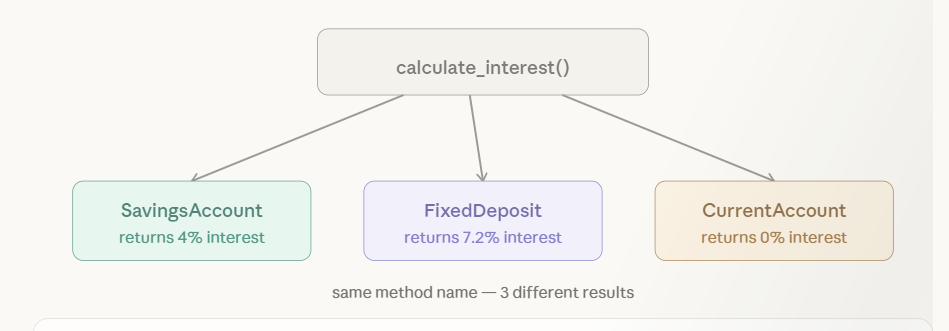

1.You call the exact same method name on different objects  
2.Each object runs its own version of that method  
3.The caller doesn't need to know which type of object it is — it just calls the method and gets the right result

* A bank teller says "process this account" to every customer who walks in. The teller does NOT check "are you savings? are you current? are you FD?" — they just say process.
* But internally, each account type processes differently — savings adds interest, current allows overdraft, FD locks money for a period.
* The teller uses one instruction → multiple behaviors happen. That is polymorphism.

### With polymorphism
Teller says only:

"process()" → correct thing happens automatically

Add 10 new account types — teller's code never changes. Each new type just defines its own process() and it works.

In [3]:
class BankAccount:
    def __init__(self, owner, balance):
        self.owner = owner
        self.balance = balance

    def calculate_interest(self):    # base version
        return 0                       # no interest by default


class SavingsAccount(BankAccount):
    def calculate_interest(self):    # OVERRIDES parent
        return self.balance * 0.04    # 4% for savings


class FixedDeposit(BankAccount):
    def calculate_interest(self):    # OVERRIDES parent
        return self.balance * 0.072   # 7.2% for FD


class CurrentAccount(BankAccount):
    pass                             # no override → uses parent's 0

In [5]:
# Calling the same method on different objects
s = SavingsAccount("Aishwarya", 100000)
f = FixedDeposit("Aishu", 100000)
c = CurrentAccount("Aishwarya_M", 100000)

print(s.calculate_interest())   
print(f.calculate_interest())   
print(c.calculate_interest())   

4000.0
7199.999999999999
0


### 5. Abstraction
Define a contract (abstract class) that all account types must follow, hiding complex implementation details.

When you use a bank app, you press "Transfer" — you don't know if it uses NEFT, RTGS, or IMPS internally. That's abstraction.

In [6]:
from abc import ABC, abstractmethod

class AbstractBankAccount(ABC):  # Abstract base class

    @abstractmethod
    def deposit(self, amount):
        pass                     # Must implement in child

    @abstractmethod
    def withdraw(self, amount):
        pass                     # Must implement in child

    @abstractmethod
    def calculate_interest(self):
        pass

    def print_statement(self):   # Concrete method — shared
        print(f"Balance: ₹{self.get_balance()}")
        print(f"Interest: ₹{self.calculate_interest()}")


class SavingsAccount(AbstractBankAccount):
    def __init__(self, balance):
        self.__balance = balance

    def deposit(self, amount):    # Must define this
        self.__balance += amount

    def withdraw(self, amount):   # Must define this
        if amount <= self.__balance:
            self.__balance -= amount

    def calculate_interest(self): # Must define this
        return self.__balance * 0.04

    def get_balance(self):
        return self.__balance

# This will raise an error — abstract class can't be instantiated!
# acc = AbstractBankAccount()  ← TypeError

acc = SavingsAccount(50000)
acc.deposit(10000)
acc.print_statement()          # Uses abstract base method

Balance: ₹60000
Interest: ₹2400.0


* @abstractmethod forces child classes to implement the method — like a legal contract
* If a child doesn't implement all abstract methods, Python raises an error on instantiation
* Concrete methods in abstract class (like print_statement) are shared freely